In [78]:
# Import Libraries

import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [79]:
# Load Dataset

df = pd.read_csv(
    "/content/drive/MyDrive/Heart Disease Cleveland UCI/heart_cleveland_upload.csv"
)

In [80]:
# Features and Target

X = df.drop("condition", axis=1)

y = df["condition"]

In [81]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [82]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [83]:
# Initialize Models

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "LDA":
        LinearDiscriminantAnalysis(),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "MLP":
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=1000,
            random_state=42
        )

}

In [84]:
# Create Empty Results List

results = []

In [85]:
# Train All Models and Collect Metrics

for name, model in models.items():

    print("=" * 70)
    print(name)

    # Use scaled data for these models
    if name in ["Logistic Regression", "LDA", "KNN", "SVM", "MLP"]:

        Xtr = X_train_scaled
        Xte = X_test_scaled

    else:

        Xtr = X_train
        Xte = X_test

    # Training Time
    start_train = time.time()

    model.fit(Xtr, y_train)

    train_time = time.time() - start_train

    # Prediction Time
    start_test = time.time()

    y_pred = model.predict(Xte)

    y_prob = model.predict_proba(Xte)[:, 1]

    test_time = time.time() - start_test

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    mcc = matthews_corrcoef(y_test, y_pred)

    kappa = cohen_kappa_score(y_test, y_pred)

    loss = log_loss(y_test, y_prob)

    # Cross Validation
    if name in ["Logistic Regression", "LDA", "KNN", "SVM", "MLP"]:

        cv_scores = cross_val_score(
            model,
            scaler.fit_transform(X),
            y,
            cv=10,
            scoring="accuracy",
            n_jobs=-1
        )

    else:

        cv_scores = cross_val_score(
            model,
            X,
            y,
            cv=10,
            scoring="accuracy",
            n_jobs=-1
        )

    cv_mean = cv_scores.mean()

    cv_std = cv_scores.std()

    # Save Results
    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC_AUC": roc_auc,

        "Balanced_Accuracy": balanced_acc,

        "MCC": mcc,

        "Kappa": kappa,

        "Log_Loss": loss,

        "CV_Mean": cv_mean,

        "CV_STD": cv_std,

        "Train_Time": train_time,

        "Predict_Time": test_time

    })

    print("Completed")

Logistic Regression
Completed
LDA
Completed
KNN
Completed
Naive Bayes
Completed
Decision Tree
Completed
Random Forest
Completed
SVM
Completed
AdaBoost
Completed
Gradient Boosting
Completed
MLP
Completed


In [86]:
# Create Comparison DataFrame

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Balanced_Accuracy,MCC,Kappa,Log_Loss,CV_Mean,CV_STD,Train_Time,Predict_Time
0,Logistic Regression,0.916667,1.000000,0.821429,0.901961,0.953125,0.910714,0.842867,0.830700,0.284270,0.831609,0.104607,0.006258,0.000790
1,LDA,0.900000,1.000000,0.785714,0.880000,0.952009,0.892857,0.813421,0.796380,0.290883,0.831609,0.106564,0.002948,0.000913
2,KNN,0.900000,1.000000,0.785714,0.880000,0.959263,0.892857,0.813421,0.796380,0.824578,0.817931,0.111453,0.001906,0.005023
3,Naive Bayes,0.866667,1.000000,0.714286,0.833333,0.912946,0.857143,0.755929,0.727273,0.432591,0.831149,0.116645,0.008114,0.008909
4,Decision Tree,0.783333,0.800000,0.714286,0.754717,0.779018,0.779018,0.564692,0.561798,7.809458,0.670000,0.159420,0.005932,0.003866
5,Random Forest,0.883333,0.956522,0.785714,0.862745,0.940290,0.877232,0.774155,0.762980,0.346854,0.787471,0.135086,0.293373,0.032070
6,SVM,0.900000,1.000000,0.785714,0.880000,0.939732,0.892857,0.813421,0.796380,0.324622,0.824713,0.095774,0.012714,0.001764
7,AdaBoost,0.850000,0.952381,0.714286,0.816327,0.935268,0.841518,0.714423,0.693878,0.524595,0.807701,0.094371,0.104976,0.022080
8,Gradient Boosting,0.866667,0.916667,0.785714,0.846154,0.926339,0.861607,0.736485,0.729730,0.333666,0.730115,0.147426,0.174476,0.006269
9,MLP,0.850000,0.880000,0.785714,0.830189,0.926339,0.845982,0.700219,0.696629,0.464822,0.784598,0.128779,3.826160,0.002972


In [87]:
# Round Values

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Balanced_Accuracy,MCC,Kappa,Log_Loss,CV_Mean,CV_STD,Train_Time,Predict_Time
0,Logistic Regression,0.9167,1.0000,0.8214,0.9020,0.9531,0.9107,0.8429,0.8307,0.2843,0.8316,0.1046,0.0063,0.0008
1,LDA,0.9000,1.0000,0.7857,0.8800,0.9520,0.8929,0.8134,0.7964,0.2909,0.8316,0.1066,0.0029,0.0009
2,KNN,0.9000,1.0000,0.7857,0.8800,0.9593,0.8929,0.8134,0.7964,0.8246,0.8179,0.1115,0.0019,0.0050
3,Naive Bayes,0.8667,1.0000,0.7143,0.8333,0.9129,0.8571,0.7559,0.7273,0.4326,0.8311,0.1166,0.0081,0.0089
4,Decision Tree,0.7833,0.8000,0.7143,0.7547,0.7790,0.7790,0.5647,0.5618,7.8095,0.6700,0.1594,0.0059,0.0039
5,Random Forest,0.8833,0.9565,0.7857,0.8627,0.9403,0.8772,0.7742,0.7630,0.3469,0.7875,0.1351,0.2934,0.0321
6,SVM,0.9000,1.0000,0.7857,0.8800,0.9397,0.8929,0.8134,0.7964,0.3246,0.8247,0.0958,0.0127,0.0018
7,AdaBoost,0.8500,0.9524,0.7143,0.8163,0.9353,0.8415,0.7144,0.6939,0.5246,0.8077,0.0944,0.1050,0.0221
8,Gradient Boosting,0.8667,0.9167,0.7857,0.8462,0.9263,0.8616,0.7365,0.7297,0.3337,0.7301,0.1474,0.1745,0.0063
9,MLP,0.8500,0.8800,0.7857,0.8302,0.9263,0.8460,0.7002,0.6966,0.4648,0.7846,0.1288,3.8262,0.0030


In [88]:
# Save Comparison Table

comparison_df.to_csv(
    "comparison.csv",
    index=False
)

print("comparison.csv saved successfully.")

comparison.csv saved successfully.


In [89]:
# Display Comparison Table

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Balanced_Accuracy,MCC,Kappa,Log_Loss,CV_Mean,CV_STD,Train_Time,Predict_Time
0,Logistic Regression,0.9167,1.0000,0.8214,0.9020,0.9531,0.9107,0.8429,0.8307,0.2843,0.8316,0.1046,0.0063,0.0008
1,LDA,0.9000,1.0000,0.7857,0.8800,0.9520,0.8929,0.8134,0.7964,0.2909,0.8316,0.1066,0.0029,0.0009
2,KNN,0.9000,1.0000,0.7857,0.8800,0.9593,0.8929,0.8134,0.7964,0.8246,0.8179,0.1115,0.0019,0.0050
3,Naive Bayes,0.8667,1.0000,0.7143,0.8333,0.9129,0.8571,0.7559,0.7273,0.4326,0.8311,0.1166,0.0081,0.0089
4,Decision Tree,0.7833,0.8000,0.7143,0.7547,0.7790,0.7790,0.5647,0.5618,7.8095,0.6700,0.1594,0.0059,0.0039
5,Random Forest,0.8833,0.9565,0.7857,0.8627,0.9403,0.8772,0.7742,0.7630,0.3469,0.7875,0.1351,0.2934,0.0321
6,SVM,0.9000,1.0000,0.7857,0.8800,0.9397,0.8929,0.8134,0.7964,0.3246,0.8247,0.0958,0.0127,0.0018
7,AdaBoost,0.8500,0.9524,0.7143,0.8163,0.9353,0.8415,0.7144,0.6939,0.5246,0.8077,0.0944,0.1050,0.0221
8,Gradient Boosting,0.8667,0.9167,0.7857,0.8462,0.9263,0.8616,0.7365,0.7297,0.3337,0.7301,0.1474,0.1745,0.0063
9,MLP,0.8500,0.8800,0.7857,0.8302,0.9263,0.8460,0.7002,0.6966,0.4648,0.7846,0.1288,3.8262,0.0030


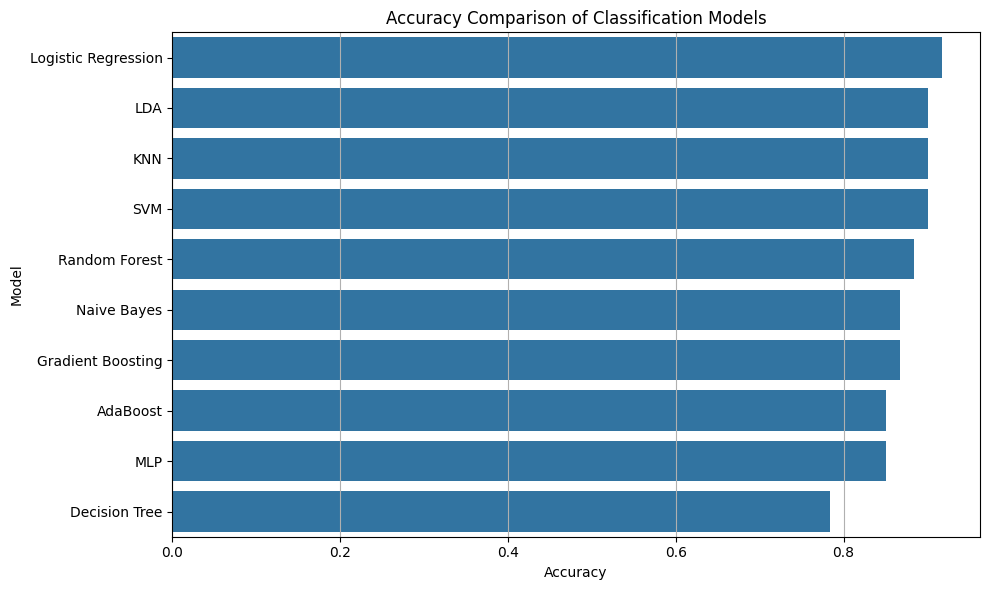

In [90]:
# Accuracy Comparison

plt.figure(figsize=(10,6))

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

sns.barplot(
    data=comparison_df,
    x="Accuracy",
    y="Model"
)

plt.title("Accuracy Comparison of Classification Models")

plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

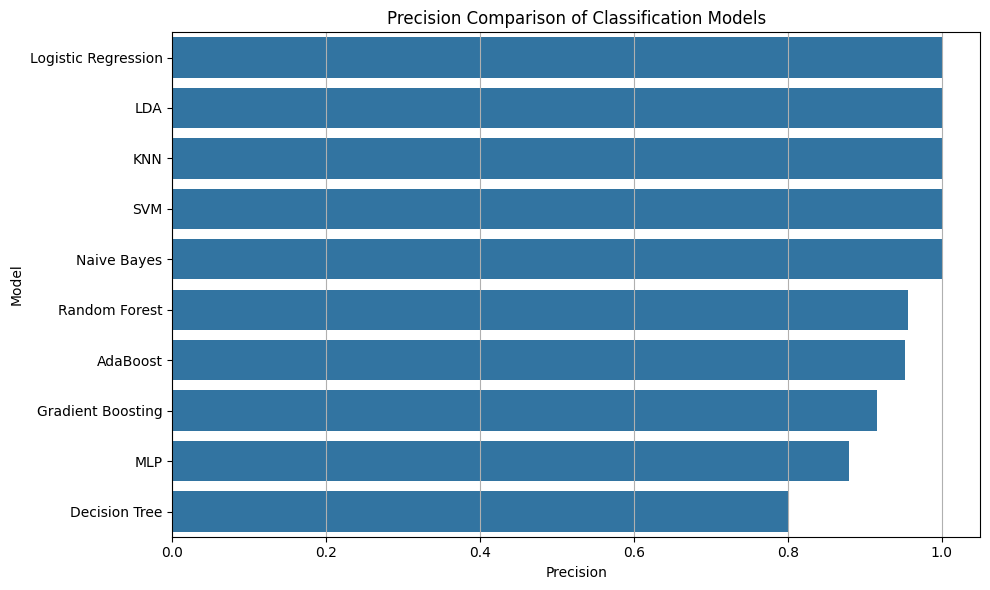

In [91]:
# Precision Comparison

plt.figure(figsize=(10,6))

comparison_df = comparison_df.sort_values(
    by="Precision",
    ascending=False
)

sns.barplot(
    data=comparison_df,
    x="Precision",
    y="Model"
)

plt.title("Precision Comparison of Classification Models")

plt.xlabel("Precision")
plt.ylabel("Model")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

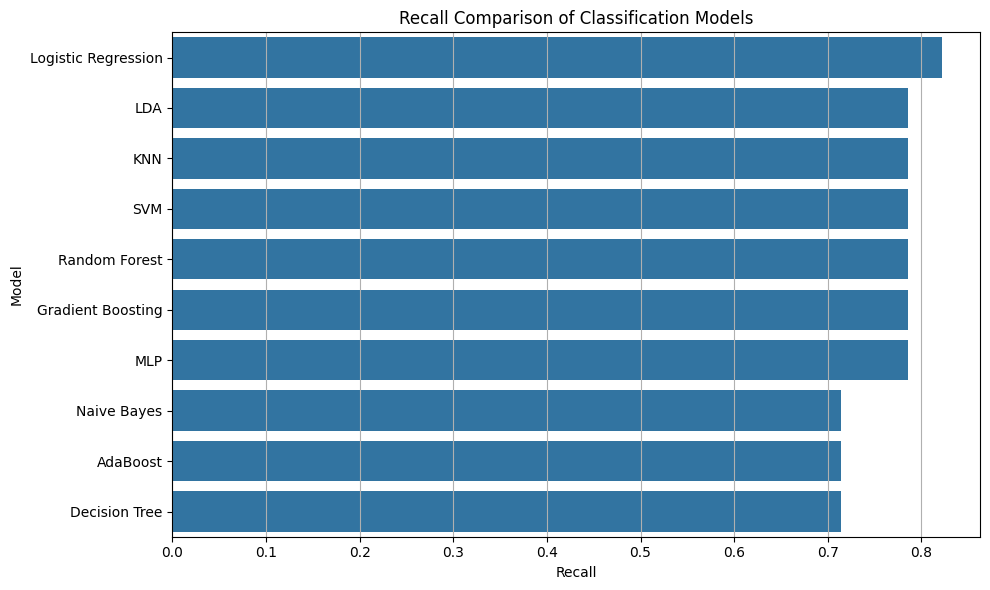

In [92]:
# Recall Comparison

plt.figure(figsize=(10,6))

comparison_df = comparison_df.sort_values(
    by="Recall",
    ascending=False
)

sns.barplot(
    data=comparison_df,
    x="Recall",
    y="Model"
)

plt.title("Recall Comparison of Classification Models")

plt.xlabel("Recall")
plt.ylabel("Model")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

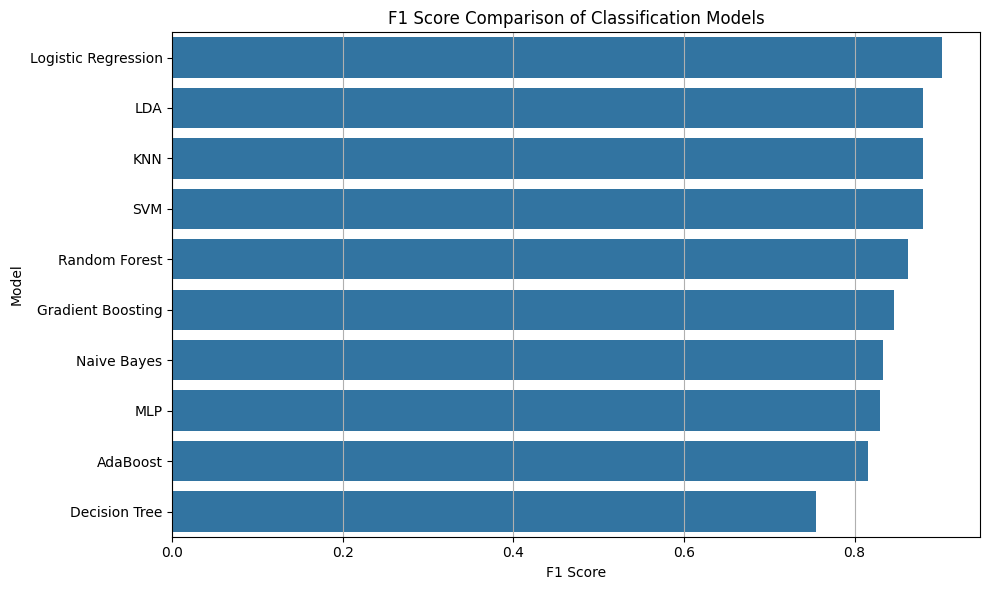

In [93]:
# F1 Score Comparison

plt.figure(figsize=(10,6))

comparison_df = comparison_df.sort_values(
    by="F1",
    ascending=False
)

sns.barplot(
    data=comparison_df,
    x="F1",
    y="Model"
)

plt.title("F1 Score Comparison of Classification Models")

plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

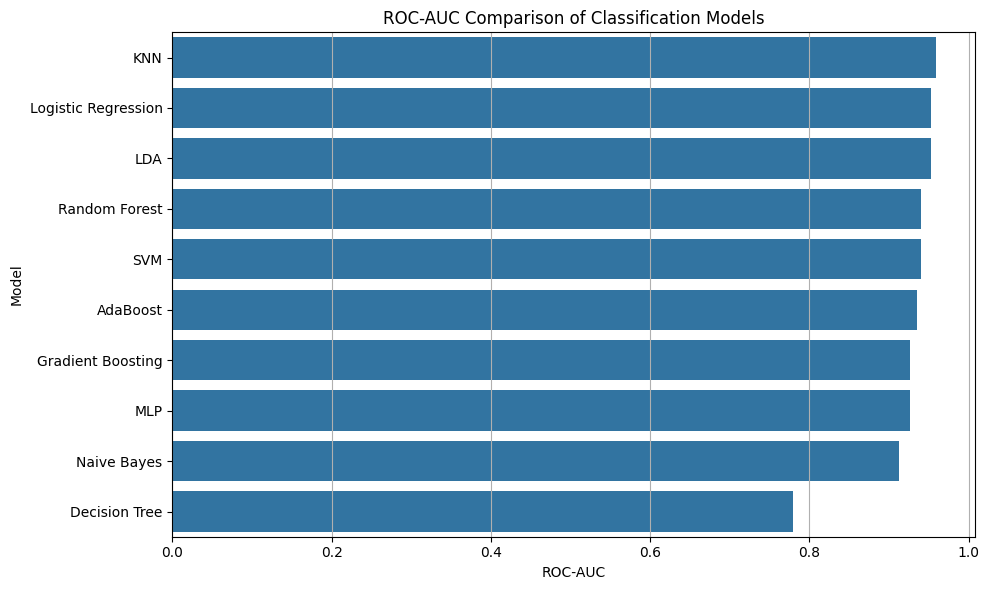

In [94]:
# ROC-AUC Comparison

plt.figure(figsize=(10,6))

comparison_df = comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

sns.barplot(
    data=comparison_df,
    x="ROC_AUC",
    y="Model"
)

plt.title("ROC-AUC Comparison of Classification Models")

plt.xlabel("ROC-AUC")
plt.ylabel("Model")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

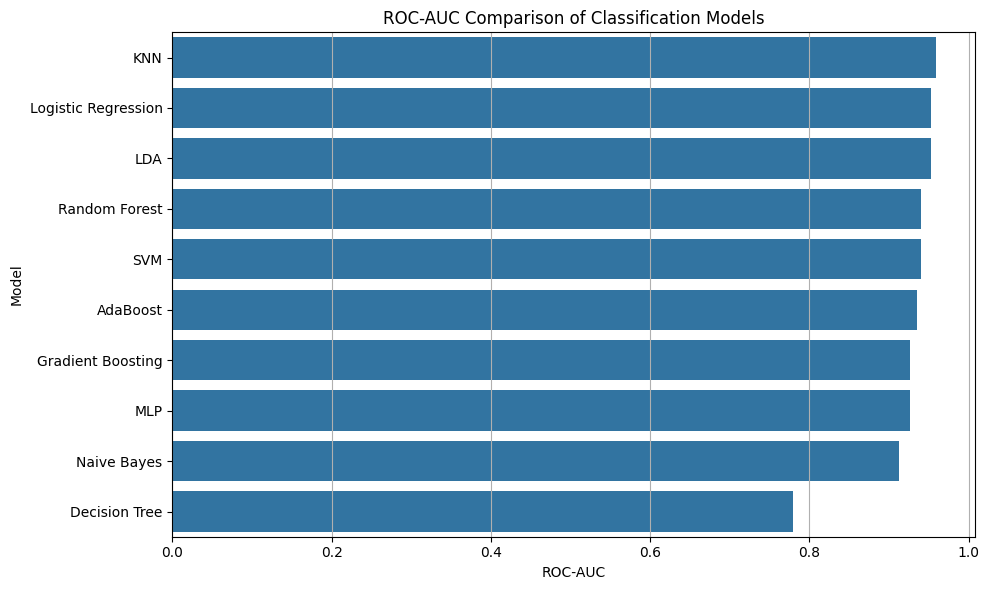

In [95]:
# ROC-AUC Comparison

plt.figure(figsize=(10,6))

comparison_df = comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

sns.barplot(
    data=comparison_df,
    x="ROC_AUC",
    y="Model"
)

plt.title("ROC-AUC Comparison of Classification Models")

plt.xlabel("ROC-AUC")
plt.ylabel("Model")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

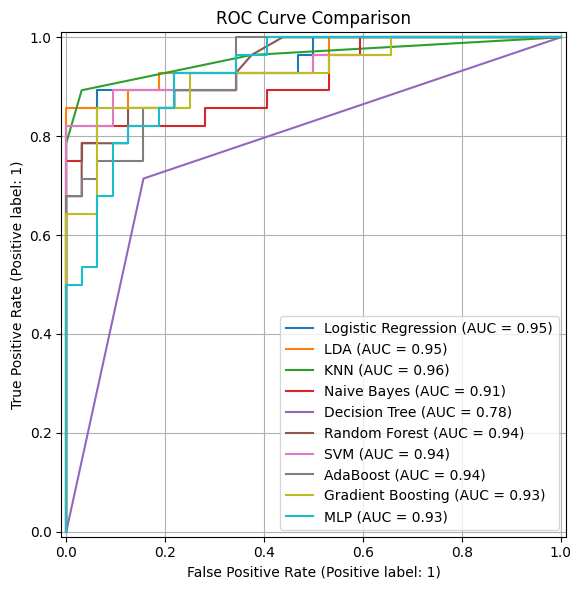

In [96]:
# Combined ROC Curve

plt.figure(figsize=(8,6))

for name, model in models.items():

    if name in ["Logistic Regression", "LDA", "KNN", "SVM", "MLP"]:

        Xtr = X_train_scaled
        Xte = X_test_scaled

    else:

        Xtr = X_train
        Xte = X_test

    model.fit(Xtr, y_train)

    RocCurveDisplay.from_estimator(
        model,
        Xte,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("ROC Curve Comparison")

plt.grid(True)

plt.tight_layout()

plt.show()

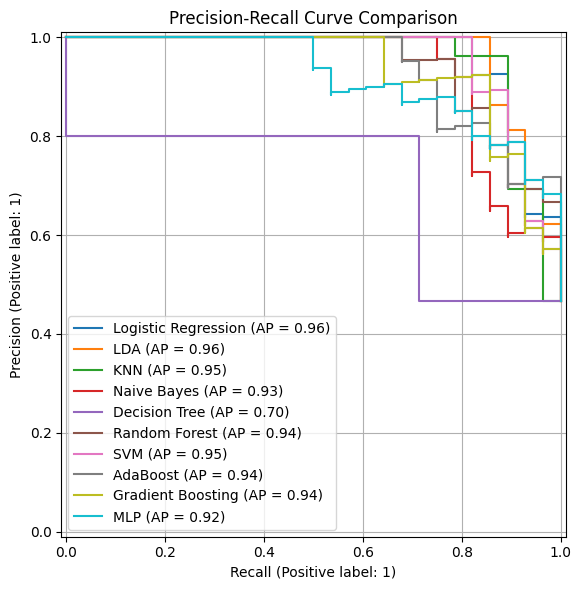

In [97]:
# Combined Precision-Recall Curve

plt.figure(figsize=(8,6))

for name, model in models.items():

    if name in ["Logistic Regression", "LDA", "KNN", "SVM", "MLP"]:

        Xtr = X_train_scaled
        Xte = X_test_scaled

    else:

        Xtr = X_train
        Xte = X_test

    model.fit(Xtr, y_train)

    PrecisionRecallDisplay.from_estimator(
        model,
        Xte,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("Precision-Recall Curve Comparison")

plt.grid(True)

plt.tight_layout()

plt.show()

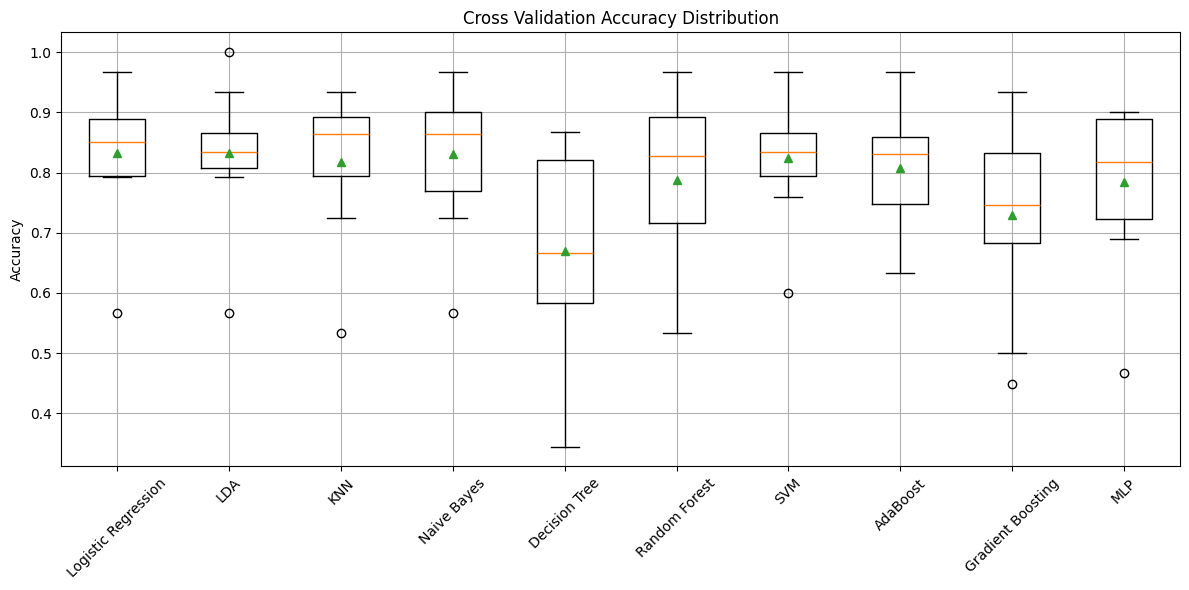

In [98]:
# Cross Validation Boxplot

cv_results = []

for name, model in models.items():

    if name in ["Logistic Regression", "LDA", "KNN", "SVM", "MLP"]:

        scores = cross_val_score(
            model,
            scaler.fit_transform(X),
            y,
            cv=10,
            scoring="accuracy",
            n_jobs=-1
        )

    else:

        scores = cross_val_score(
            model,
            X,
            y,
            cv=10,
            scoring="accuracy",
            n_jobs=-1
        )

    cv_results.append(scores)

plt.figure(figsize=(12,6))

plt.boxplot(
    cv_results,
    labels=models.keys(),
    showmeans=True
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Cross Validation Accuracy Distribution")

plt.grid(True)

plt.tight_layout()

plt.show()

In [99]:
# Best Model Ranking

ranking = comparison_df.sort_values(
    by=[
        "F1",
        "ROC_AUC",
        "Accuracy"
    ],
    ascending=False
)

ranking.insert(
    0,
    "Rank",
    range(1, len(ranking)+1)
)

display(ranking)

,Rank,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Balanced_Accuracy,MCC,Kappa,Log_Loss,CV_Mean,CV_STD,Train_Time,Predict_Time
0,1,Logistic Regression,0.9167,1.0000,0.8214,0.9020,0.9531,0.9107,0.8429,0.8307,0.2843,0.8316,0.1046,0.0063,0.0008
2,2,KNN,0.9000,1.0000,0.7857,0.8800,0.9593,0.8929,0.8134,0.7964,0.8246,0.8179,0.1115,0.0019,0.0050
1,3,LDA,0.9000,1.0000,0.7857,0.8800,0.9520,0.8929,0.8134,0.7964,0.2909,0.8316,0.1066,0.0029,0.0009
6,4,SVM,0.9000,1.0000,0.7857,0.8800,0.9397,0.8929,0.8134,0.7964,0.3246,0.8247,0.0958,0.0127,0.0018
5,5,Random Forest,0.8833,0.9565,0.7857,0.8627,0.9403,0.8772,0.7742,0.7630,0.3469,0.7875,0.1351,0.2934,0.0321
8,6,Gradient Boosting,0.8667,0.9167,0.7857,0.8462,0.9263,0.8616,0.7365,0.7297,0.3337,0.7301,0.1474,0.1745,0.0063
3,7,Naive Bayes,0.8667,1.0000,0.7143,0.8333,0.9129,0.8571,0.7559,0.7273,0.4326,0.8311,0.1166,0.0081,0.0089
9,8,MLP,0.8500,0.8800,0.7857,0.8302,0.9263,0.8460,0.7002,0.6966,0.4648,0.7846,0.1288,3.8262,0.0030
7,9,AdaBoost,0.8500,0.9524,0.7143,0.8163,0.9353,0.8415,0.7144,0.6939,0.5246,0.8077,0.0944,0.1050,0.0221
4,10,Decision Tree,0.7833,0.8000,0.7143,0.7547,0.7790,0.7790,0.5647,0.5618,7.8095,0.6700,0.1594,0.0059,0.0039


In [100]:
# Save Best Model

ranking.to_csv(
    "best_model.csv",
    index=False
)

print("best_model.csv saved successfully.")

best_model.csv saved successfully.
